In [1]:
import bw2data, bw2io, bw2calc
from bw_timex import TimexLCA
from bw_temporalis import TemporalDistribution, easy_timedelta_distribution
import numpy as np
from datetime import datetime
import os
import re
import pandas as pd
import numpy as np

In [2]:
import sys
sys.path.append('../utils/') 
from elec_builder import *

In [3]:
# activate the bw project
bw2data.projects.set_current("ei311")
#for db in bw2data.databases:
#    print(db, len(bw2data.Database(db)))

### 1. building hydro_foreground 
- for China, there’s no reservoir system, so we choose the pumped storage for the province where the three Gorges dam project (hubei was chosen per below Google map) 
- for hydro for the U.S., it’s the northwest and rockies (so mapping to US-WECC) [https://www.eia.gov/todayinenergy/detail.php?id=61883] generate highest hydro, and a reservoir system should be chosen [https://www.osti.gov/servlets/purl/1884284#:~:text=2.1.1.,2]

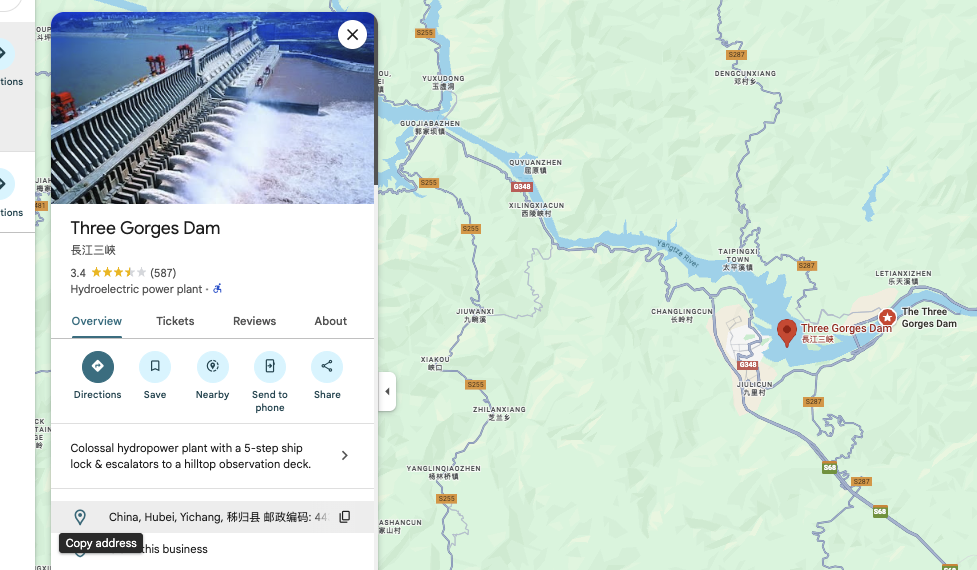


In [4]:
hydro_cn = ['CN-HB']
hydro_us = ['US-WECC' ]

xx = build_dynamic_electricity_all(
    locations = hydro_cn , 
    pathways = [ "SSP1-VLLO" , "SSP2-M", "SSP5-H" ],
    years = [2030, 2040, 2050], 
    elec_act = 'electricity production, hydro, pumped storage',
    ref_name = 'market for electricity, hydro, high voltage',
    fg_db_name="elec_hydro_foreground",
    flush_fg_db = True
)

# not tested: assign_td_from_results_dict(results_dict = xx, elec_td_year=10)

pathways should match the premise database names, e.g., SSP1-VLLO, SSP2-M, SSP5-H 
 also IAM locations for premise database can be found through calling: 
 from premise import geomap -> premise.geomap.Geomap('image').iam_regions 
Created fresh foreground DB: 'elec_hydro_foreground'


In [5]:
hydro_db = bw2data.Database("elec_hydro_foreground")
len(hydro_db)

9

In [6]:
yy =  build_dynamic_electricity_all(
    locations = hydro_us , 
    pathways = [ "SSP1-VLLO" , "SSP2-M", "SSP5-H" ],
    years = [2030, 2040, 2050], 
    elec_act = 'electricity production, hydro, reservoir, alpine region',
    ref_name = 'market for electricity, hydro, high voltage',
    fg_db_name="elec_hydro_foreground",
    flush_fg_db = False
)

pathways should match the premise database names, e.g., SSP1-VLLO, SSP2-M, SSP5-H 
 also IAM locations for premise database can be found through calling: 
 from premise import geomap -> premise.geomap.Geomap('image').iam_regions 
Using foreground DB: elec_hydro_foreground, with 9 activities currently.


In [7]:
len(hydro_db)

18

In [8]:
act_list = list(hydro_db)[2:4]
for act in act_list:
    tech_excs = list(act.technosphere())
    print(len(tech_excs))
    exc = tech_excs[0]
    print(exc)

1
Exchange: 1 kilowatt hour 'electricity production, hydro, reservoir, alpine region' (kilowatt hour, US-WECC, None) to 'market for electricity, hydro, high voltage, US-WECC, SSP2-M, 2050' (kWh, US-WECC, None)>
1
Exchange: 1 kilowatt hour 'electricity production, hydro, reservoir, alpine region' (kilowatt hour, US-WECC, None) to 'market for electricity, hydro, high voltage, US-WECC, SSP1-VLLO, 2040' (kWh, US-WECC, None)>


In [9]:
list(hydro_db) 

['market for electricity, hydro, high voltage, US-WECC, SSP2-M, 2050' (kWh, US-WECC, None),
 'market for electricity, hydro, high voltage, CN-HB, SSP5-H, 2040' (kWh, CN-HB, None),
 'market for electricity, hydro, high voltage, CN-HB, SSP2-M, 2040' (kWh, CN-HB, None),
 'market for electricity, hydro, high voltage, US-WECC, SSP1-VLLO, 2030' (kWh, US-WECC, None),
 'market for electricity, hydro, high voltage, US-WECC, SSP5-H, 2030' (kWh, US-WECC, None),
 'market for electricity, hydro, high voltage, CN-HB, SSP5-H, 2050' (kWh, CN-HB, None),
 'market for electricity, hydro, high voltage, US-WECC, SSP1-VLLO, 2050' (kWh, US-WECC, None),
 'market for electricity, hydro, high voltage, US-WECC, SSP5-H, 2050' (kWh, US-WECC, None),
 'market for electricity, hydro, high voltage, CN-HB, SSP1-VLLO, 2030' (kWh, CN-HB, None),
 'market for electricity, hydro, high voltage, US-WECC, SSP1-VLLO, 2040' (kWh, US-WECC, None),
 'market for electricity, hydro, high voltage, CN-HB, SSP2-M, 2030' (kWh, CN-HB, Non

In [10]:
rows = []   # collect results for all acts
act_list = list(hydro_db)   
for act in act_list: 
    print(act)

    name = act.get("name")
    name_parts = [p.strip() for p in name.split(",")]
    # run static LCI + premise_GWP vs. pGWP100 first: 
    pgwp_fixedco2 = find_dpGWP100_method(name_parts[-2], int(name_parts[-1]), method_suffix = "pGWP100 - fixed-AGWPCO2")
    pgwp_dpco2 = find_dpGWP100_method(name_parts[-2], int(name_parts[-1]), method_suffix = "pGWP100 - dp-AGWPCO2")
    gwp =  ('ecoinvent-3.11', 'IPCC 2021 (incl. biogenic CO2)', 'climate change: total (incl. biogenic CO2, incl. SLCFs)', 'global warming potential (GWP100)')   

    lca_gwp = bw2calc.lca.LCA({act: 1}, method=gwp)
    lca_gwp.lci(); lca_gwp.lcia()
    score_gwp = float(lca_gwp.score)

    lca_fixed = bw2calc.lca.LCA({act: 1}, method=pgwp_fixedco2)
    lca_fixed.lci(); lca_fixed.lcia()
    score_fixedco2 = float(lca_fixed.score)

    lca_dp = bw2calc.lca.LCA({act: 1}, method=pgwp_dpco2)
    lca_dp.lci(); lca_dp.lcia()
    score_dpco2 = float(lca_dp.score)

    print(score_gwp, score_fixedco2, score_dpco2) 

    # ---- store results for this activity ----
    rows.append({
        "Activity": name,                      # index value later
        "gwp100": score_gwp,
        "pGWP100_fixedCO2": score_fixedco2,
        "pGWP100_dpCO2": score_dpco2,
    })



'market for electricity, hydro, high voltage, CN-HB, SSP5-H, 2040' (kWh, CN-HB, None)
0.797938693780109 0.7869701540908736 0.7842300217505246
'market for electricity, hydro, high voltage, CN-HB, SSP2-M, 2030' (kWh, CN-HB, None)
0.9567833560478037 1.054402743522131 0.9423991019875643
'market for electricity, hydro, high voltage, US-WECC, SSP1-VLLO, 2040' (kWh, US-WECC, None)
0.00461213378439661 0.005161233035638555 0.004561853439353754
'market for electricity, hydro, high voltage, CN-HB, SSP5-H, 2030' (kWh, CN-HB, None)
0.9758569652285682 1.0539971935821046 0.9577719529231529
'market for electricity, hydro, high voltage, US-WECC, SSP2-M, 2030' (kWh, US-WECC, None)
0.006524554174075608 0.007154645064156576 0.006400496575023017
'market for electricity, hydro, high voltage, CN-HB, SSP2-M, 2040' (kWh, CN-HB, None)
0.805354244942026 0.8397549322939014 0.7974496094880679
'market for electricity, hydro, high voltage, US-WECC, SSP1-VLLO, 2050' (kWh, US-WECC, None)
0.0033246655191605675 0.003735

In [11]:
df_scores = pd.DataFrame(rows)
df_scores = df_scores.set_index("Activity")
df_scores

,gwp100,pGWP100_fixedCO2,pGWP100_dpCO2
Activity,,,
"market for electricity, hydro, high voltage, CN-HB, SSP5-H, 2040",0.797939,0.786970,0.784230
"market for electricity, hydro, high voltage, CN-HB, SSP2-M, 2030",0.956783,1.054403,0.942399
"market for electricity, hydro, high voltage, US-WECC, SSP1-VLLO, 2040",0.004612,0.005161,0.004562
"market for electricity, hydro, high voltage, CN-HB, SSP5-H, 2030",0.975857,1.053997,0.957772
"market for electricity, hydro, high voltage, US-WECC, SSP2-M, 2030",0.006525,0.007155,0.006400
"market for electricity, hydro, high voltage, CN-HB, SSP2-M, 2040",0.805354,0.839755,0.797450
"market for electricity, hydro, high voltage, US-WECC, SSP1-VLLO, 2050",0.003325,0.003736,0.003286
"market for electricity, hydro, high voltage, US-WECC, SSP1-VLLO, 2030",0.006423,0.007229,0.006322
"market for electricity, hydro, high voltage, CN-HB, SSP1-VLLO, 2030",0.914716,1.033251,0.902619


In [12]:
df2 = df_scores.sort_values(by=['Activity'])
df2 
#

,gwp100,pGWP100_fixedCO2,pGWP100_dpCO2
Activity,,,
"market for electricity, hydro, high voltage, CN-HB, SSP1-VLLO, 2030",0.914716,1.033251,0.902619
"market for electricity, hydro, high voltage, CN-HB, SSP1-VLLO, 2040",0.117600,0.131532,0.116229
"market for electricity, hydro, high voltage, CN-HB, SSP1-VLLO, 2050",0.076874,0.086286,0.075920
"market for electricity, hydro, high voltage, CN-HB, SSP2-M, 2030",0.956783,1.054403,0.942399
"market for electricity, hydro, high voltage, CN-HB, SSP2-M, 2040",0.805354,0.839755,0.797450
"market for electricity, hydro, high voltage, CN-HB, SSP2-M, 2050",0.595360,0.588838,0.591614
"market for electricity, hydro, high voltage, CN-HB, SSP5-H, 2030",0.975857,1.053997,0.957772
"market for electricity, hydro, high voltage, CN-HB, SSP5-H, 2040",0.797939,0.786970,0.784230
"market for electricity, hydro, high voltage, CN-HB, SSP5-H, 2050",0.578654,0.516551,0.571484


In [13]:
df2.to_excel("dp-LCI_output/staticLCI_(p)GWP100/hydro_CN-pumped_US-reservoir_staticLCI_threeGWP100.xlsx")

### 2. building dpLCI

In [4]:
pv_db = bw2data.Database('elec_PV_foreground')
len(list(pv_db) )

18

In [5]:
database_dates = {
    'ei_cutoff_3.11_image_SSP1-VLLO_2030 2025-11-24': datetime.strptime("2030", "%Y"),
    'ei_cutoff_3.11_image_SSP1-VLLO_2040 2025-11-22': datetime.strptime("2040", "%Y"),
    'ei_cutoff_3.11_image_SSP1-VLLO_2050 2025-11-22': datetime.strptime("2050", "%Y"),

    'ei_cutoff_3.11_image_SSP2-M_2030 2025-11-22': datetime.strptime("2030", "%Y"),
    'ei_cutoff_3.11_image_SSP2-M_2040 2025-11-22': datetime.strptime("2040", "%Y"),
    'ei_cutoff_3.11_image_SSP2-M_2050 2025-11-22': datetime.strptime("2050", "%Y"),

    'ei_cutoff_3.11_image_SSP5-H_2030 2025-11-22': datetime.strptime("2030", "%Y"),
    'ei_cutoff_3.11_image_SSP5-H_2040 2025-11-22': datetime.strptime("2040", "%Y"),
    'ei_cutoff_3.11_image_SSP5-H_2050 2025-11-22': datetime.strptime("2050", "%Y"),
    
    "elec_PV_foreground": "dynamic", # flag databases that should be temporally distributed with "dynamic"
}


In [7]:
select_acts = list(pv_db)[2]
select_acts

'market for electricity, PV, low voltage, CN, SSP5-H, 2030' (kWh, CN, None)

In [8]:
dp_results = {}

for act in list(pv_db): 
    print(act)
 
    #### dynamic LCI:: 
    assign_td_from_foreground_db( 
        select_act = act,
        elec_td_year=10,
        resolution="Y",
        kind="uniform",
        fg_db_name="elec_PV_foreground",
        verbose = True
     )

    tlca = run_dp_timex_lca(foreground_act = act ,   
                    pathway = None,
                    year = None,
                    method = None,
                    database_dates = database_dates, #None not working, has to incl. all 9 background DB ... 
                    temporal_grouping="year", 
                    method_prefix = "Climate Change prospective GWP100",
                    method_suffix = "pGWP100 - fixed-AGWPCO2", 
                    fg_db_name = 'elec_PV_foreground'
     )

    tlca.lci()
    tlca.dynamic_inventory.shape

    # dyn-foreground LCI + static background LCI + pGWP100
    lca_0 = tlca.base_score 
    
    # dpLCI (dyn-foreground LCI + dyn background LCI) +  pGWP100
    tlca.static_lcia()
    lca_1 = tlca.static_score


    act_name = act.get("name")
    dp_results[act_name] = {
        "dyn FG LCI static BG p-LCI, pGWP100-fixedCO2": float(lca_0),   # static BG LCI + dyn FG LCI
        "full dp-LCI, pGWP100-fixedCO2": float(lca_1),      # dyn BG LCI + dyn FG LCI
    }

    
    #### now save all dyLCI flows to pandas 
    df = tlca.dynamic_inventory_df

    ##### important to convert flow and act as str to excel 
    df["flow"] = df["flow"].astype(str)
    df["activity"] = df["activity"].astype(str)

    ### export df to dp-LCI_output folder, using the act name as the excel name 
    out_dir = "dp-LCI_output"
    os.makedirs(out_dir, exist_ok=True)    
    raw_name = act["name"]
    safe_name = re.sub(r"[^A-Za-z0-9_\-()]+", "_", raw_name)   # replace spaces/special chars
    
    excel_path = os.path.join(out_dir, f"{safe_name}.xlsx")
    
    df.to_excel(excel_path, index=False)    
    print(f"✔ Exported dynamic inventory DF for '{raw_name}' → {excel_path}")
    

2025-12-05 14:16:16.493 | INFO     | bw_timex.timex_lca:__init__:114 - Initializing TimexLCA object...
2025-12-05 14:16:16.494 | INFO     | bw_timex.timex_lca:__init__:136 - Collecting node infos...


'market for electricity, PV, low voltage, US, SSP5-H, 2030' (kWh, US, None)
TD applied to 'market for electricity, PV, low voltage, US, SSP5-H, 2030' → Exchange: 1 kilowatt hour 'electricity production, photovoltaic, commercial' (kilowatt hour, US, None) to 'market for electricity, PV, low voltage, US, SSP5-H, 2030' (kWh, US, None)>
for the activity 'market for electricity, PV, low voltage, US, SSP5-H, 2030' (kWh, US, None),it's under SSP-SSP5-H, year-2030 
 we'll use LCIA ('Climate Change prospective GWP100', 'SSP585', 'MY2030', 'pGWP100 - fixed-AGWPCO2')  with background database.datetime = {'ei_cutoff_3.11_image_SSP1-VLLO_2030 2025-11-24': datetime.datetime(2030, 1, 1, 0, 0), 'ei_cutoff_3.11_image_SSP1-VLLO_2040 2025-11-22': datetime.datetime(2040, 1, 1, 0, 0), 'ei_cutoff_3.11_image_SSP1-VLLO_2050 2025-11-22': datetime.datetime(2050, 1, 1, 0, 0), 'ei_cutoff_3.11_image_SSP2-M_2030 2025-11-22': datetime.datetime(2030, 1, 1, 0, 0), 'ei_cutoff_3.11_image_SSP2-M_2040 2025-11-22': datetim

2025-12-05 14:19:21.045 | INFO     | bw_timex.timex_lca:build_timeline:216 - No edge filter function provided. Skipping all edges in background databases.
2025-12-05 14:20:54.968 | INFO     | bw_timex.timex_lca:build_timeline:232 - Calculating base LCA...
2025-12-05 14:21:21.291 | INFO     | bw_timex.timex_lca:build_timeline:242 - Creating activity time mapping...
2025-12-05 14:21:23.821 | INFO     | bw_timex.timeline_builder:__init__:99 - Traversing supply chain graph...


Starting graph traversal


2025-12-05 14:21:25.366 | INFO     | bw_timex.timeline_builder:build_timeline:142 - Building timeline...
2025-12-05 14:21:25.449 | INFO     | bw_timex.timeline_builder:get_weights_for_interpolation_between_nearest_years:522 - Reference date 2026-01-01 00:00:00 is lower than all provided dates. Data will be taken from the closest higher year.
2025-12-05 14:21:25.450 | INFO     | bw_timex.timeline_builder:get_weights_for_interpolation_between_nearest_years:522 - Reference date 2026-01-01 00:00:00 is lower than all provided dates. Data will be taken from the closest higher year.
2025-12-05 14:21:25.451 | INFO     | bw_timex.timeline_builder:get_weights_for_interpolation_between_nearest_years:522 - Reference date 2027-01-01 00:00:00 is lower than all provided dates. Data will be taken from the closest higher year.
2025-12-05 14:21:25.452 | INFO     | bw_timex.timeline_builder:get_weights_for_interpolation_between_nearest_years:522 - Reference date 2028-01-01 00:00:00 is lower than all prov

...

Starting graph traversal


2025-12-05 18:02:02.106 | INFO     | bw_timex.timeline_builder:build_timeline:142 - Building timeline...


Calculation count: 1


2025-12-05 18:02:02.334 | INFO     | bw_timex.timeline_builder:get_weights_for_interpolation_between_nearest_years:522 - Reference date 2026-01-01 00:00:00 is lower than all provided dates. Data will be taken from the closest higher year.
2025-12-05 18:02:02.337 | INFO     | bw_timex.timeline_builder:get_weights_for_interpolation_between_nearest_years:522 - Reference date 2026-01-01 00:00:00 is lower than all provided dates. Data will be taken from the closest higher year.
2025-12-05 18:02:02.342 | INFO     | bw_timex.timeline_builder:get_weights_for_interpolation_between_nearest_years:522 - Reference date 2027-01-01 00:00:00 is lower than all provided dates. Data will be taken from the closest higher year.
2025-12-05 18:02:02.346 | INFO     | bw_timex.timeline_builder:get_weights_for_interpolation_between_nearest_years:522 - Reference date 2028-01-01 00:00:00 is lower than all provided dates. Data will be taken from the closest higher year.
2025-12-05 18:02:02.349 | INFO     | bw_time

✔ Exported dynamic inventory DF for 'market for electricity, PV, low voltage, US, SSP5-H, 2040' → dp-LCI_output/market_for_electricity_PV_low_voltage_US_SSP5-H_2040.xlsx
